# Coffee Shop ERP — Data Exploration
Quick visual pass over items, costing, and inventory using pandas + matplotlib.

In [121]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (9, 5)

conn = sqlite3.connect('../data/coffee_shop.db')

## 1. Items overview

In [122]:
items = pd.read_sql_query('SELECT * FROM items', conn)
items.groupby('item_type').size().rename('count')

item_type
finished_good     8
intermediate      5
raw_material     15
Name: count, dtype: int64

In [123]:
items[items.item_type == 'finished_good'][['item_code', 'item_name', 'standard_cost', 'sale_price']]

,item_code,item_name,standard_cost,sale_price
20,FG-LATTE-STD,Latte Standard,3.160667,4.50
21,FG-LATTE-SPICED,Spiced Latte,3.940667,5.25
22,FG-LATTE-MOCHA,Mocha Latte,3.700667,5.25
23,FG-BREWED,Brewed Coffee,2.180400,3.00
24,FG-AMERICANO,Americano,2.482667,3.75
25,FG-FRAPPE-CARAMEL,Caramel Frappe,4.542467,5.75
26,FG-FRAPPE-MOCHA,Mocha Frappe,4.502467,5.75
27,FG-COLDBREW,Cold Brew,2.669333,4.25


## 2. Margin by finished good

In [124]:
margin = pd.read_sql_query('SELECT * FROM v_item_margin ORDER BY margin_pct DESC', conn)
margin

,item_id,item_name,sale_price,standard_cost,gross_margin,margin_pct
0,28,Cold Brew,4.25,2.669333,1.580667,0.371922
1,25,Americano,3.75,2.482667,1.267333,0.337956
2,21,Latte Standard,4.50,3.160667,1.339333,0.297630
3,23,Mocha Latte,5.25,3.700667,1.549333,0.295111
4,24,Brewed Coffee,3.00,2.180400,0.819600,0.273200
5,22,Spiced Latte,5.25,3.940667,1.309333,0.249397
6,27,Mocha Frappe,5.75,4.502467,1.247533,0.216962
7,26,Caramel Frappe,5.75,4.542467,1.207533,0.210006


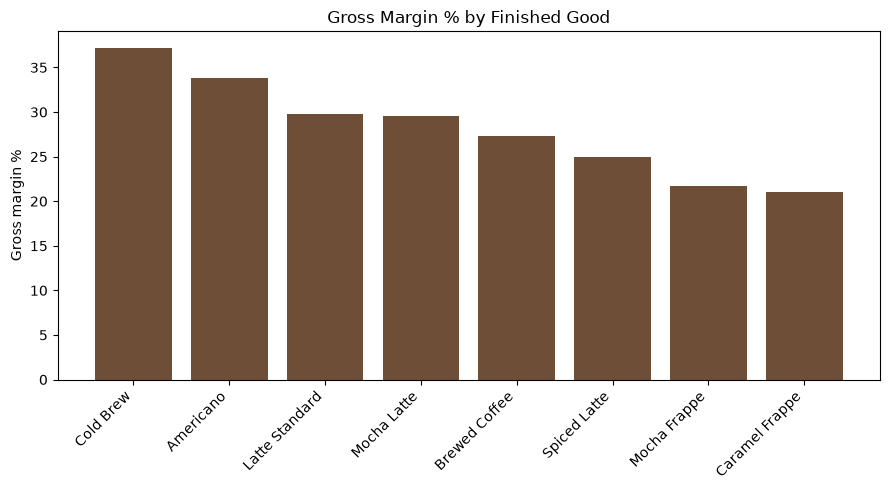

In [125]:
fig, ax = plt.subplots()
ax.bar(margin['item_name'], margin['margin_pct'] * 100, color='#6f4e37')
ax.set_ylabel('Gross margin %')
ax.set_title('Gross Margin % by Finished Good')
ax.tick_params(axis='x', rotation=45)
for label in ax.get_xticklabels():
    label.set_ha('right')
plt.tight_layout()
plt.show()

## 3. Cost breakdown: material vs. labor
Uses the same rollup logic as `costing.py`, computed here directly in pandas for exploration.

In [126]:
formulas = pd.read_sql_query('SELECT * FROM formulas', conn)
routes = pd.read_sql_query('SELECT * FROM routes', conn)
route_ops = pd.read_sql_query('SELECT * FROM route_operations', conn)
workstations = pd.read_sql_query('SELECT * FROM workstations', conn)

# labor cost per item: join routes -> route_operations -> workstations
labor = (route_ops.merge(routes, on='route_id')
                   .merge(workstations, on='workstation_id', how='left'))
labor['op_cost'] = (labor['setup_minutes'] + labor['run_minutes']) / 60 * labor['hourly_rate'].fillna(0)
labor_by_item = labor.groupby('item_id')['op_cost'].sum().rename('labor_cost')

# material cost per item: one level of formulas, using items.standard_cost as component cost
# (already rolled up bottom-up by costing.py, so this reflects the full multi-tier BOM)
comp_cost = items.set_index('item_id')['standard_cost']
formulas['component_cost'] = formulas['component_item_id'].map(comp_cost)
formulas['line_cost'] = formulas['quantity'] * (1 + formulas['scrap_pct']) * formulas['component_cost']
material_by_item = formulas.groupby('parent_item_id')['line_cost'].sum().rename('material_cost')

cost_breakdown = (items.set_index('item_id')[['item_code', 'item_type']]
                        .join(material_by_item)
                        .join(labor_by_item)
                        .fillna(0))
cost_breakdown = cost_breakdown[cost_breakdown.item_type.isin(['intermediate', 'finished_good'])]
cost_breakdown = cost_breakdown.sort_values(['item_type', 'material_cost'], ascending=[True, False])
cost_breakdown

,item_code,item_type,material_cost,labor_cost
item_id,,,,
26,FG-FRAPPE-CARAMEL,finished_good,4.042467,0.500000
27,FG-FRAPPE-MOCHA,finished_good,4.002467,0.500000
23,FG-LATTE-MOCHA,finished_good,3.200667,0.500000
22,FG-LATTE-SPICED,finished_good,3.190667,0.750000
21,FG-LATTE-STD,finished_good,2.910667,0.250000
28,FG-COLDBREW,finished_good,2.669333,0.000000
25,FG-AMERICANO,finished_good,2.482667,0.000000
24,FG-BREWED,finished_good,2.180400,0.000000
20,SFG-COLDBREW,intermediate,1.836000,0.833333


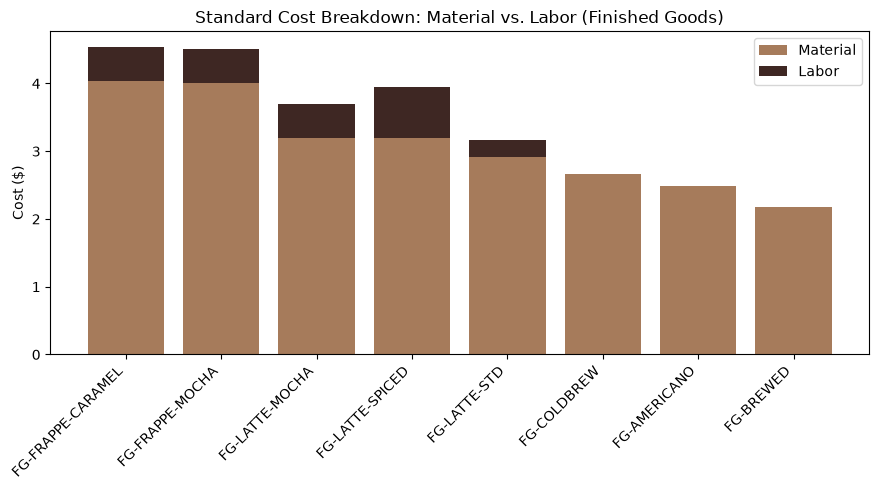

In [127]:
fig, ax = plt.subplots()
fg_breakdown = cost_breakdown[cost_breakdown.item_type == 'finished_good']
cost_breakdown_sorted = fg_breakdown.sort_values('material_cost', ascending=False)
ax.bar(cost_breakdown_sorted['item_code'], cost_breakdown_sorted['material_cost'], label='Material', color='#a67b5b')
ax.bar(cost_breakdown_sorted['item_code'], cost_breakdown_sorted['labor_cost'],
       bottom=cost_breakdown_sorted['material_cost'], label='Labor', color='#3e2723')
ax.set_ylabel('Cost ($)')
ax.set_title('Standard Cost Breakdown: Material vs. Labor (Finished Goods)')
ax.tick_params(axis='x', rotation=45)
for label in ax.get_xticklabels():
    label.set_ha('right')
ax.legend()
plt.tight_layout()
plt.show()

### 3b. Cost breakdown at the SFG (intermediate) level
This is the cost baked into each base before add-ons/finishing turn it into a sellable finished good.

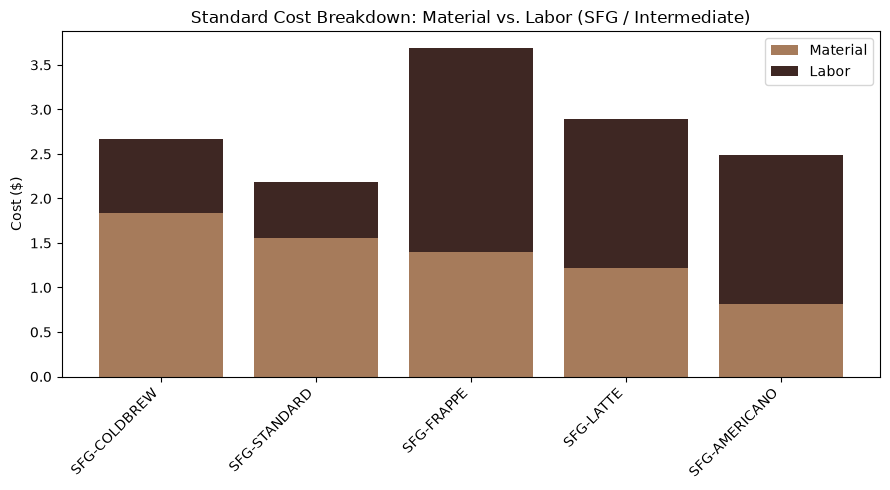

In [128]:
sfg_breakdown = cost_breakdown[cost_breakdown.item_type == 'intermediate'].sort_values('material_cost', ascending=False)

fig, ax = plt.subplots()
ax.bar(sfg_breakdown['item_code'], sfg_breakdown['material_cost'], label='Material', color='#a67b5b')
ax.bar(sfg_breakdown['item_code'], sfg_breakdown['labor_cost'],
       bottom=sfg_breakdown['material_cost'], label='Labor', color='#3e2723')
ax.set_ylabel('Cost ($)')
ax.set_title('Standard Cost Breakdown: Material vs. Labor (SFG / Intermediate)')
ax.tick_params(axis='x', rotation=45)
for label in ax.get_xticklabels():
    label.set_ha('right')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Inventory: on-hand vs. reorder point

In [129]:
inv = pd.read_sql_query('''
    SELECT it.item_code, i.on_hand_qty, i.reorder_point, i.reorder_qty, i.pack_size, i.min_order_qty
    FROM inventory i JOIN items it ON it.item_id = i.item_id
    ORDER BY it.item_code
''', conn)
inv

,item_code,on_hand_qty,reorder_point,reorder_qty,pack_size,min_order_qty
0,BASE-BREWED,1629.88,3939.19,6016.0,128.0,1.0
1,BASE-COLDBREW,1908.32,2338.09,3584.0,128.0,1.0
2,BASE-ESPRESSO,5413.32,3428.64,5248.0,128.0,1.0
3,CREAM-HH,516.98,262.61,608.0,32.0,1.0
4,CREAM-WM,2687.96,3374.68,7680.0,128.0,1.0
5,RM-CARAMELDRIZZLE,129.50,77.78,140.0,20.0,1.0
6,RM-CINNAMON,165.00,178.14,400.0,200.0,1.0
7,RM-COCOA,334.00,988.49,1500.0,500.0,1.0
8,RM-ICE,1215.40,1001.00,3520.0,320.0,1.0
9,RM-NUTMEG,165.00,178.14,400.0,200.0,1.0


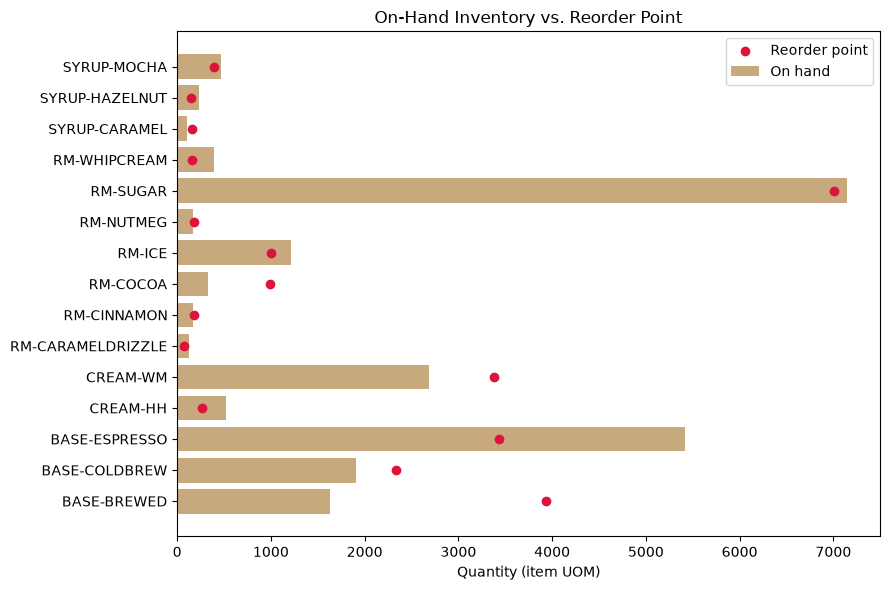

In [130]:
fig, ax = plt.subplots(figsize=(9, 6))
y = range(len(inv))
ax.barh(y, inv['on_hand_qty'], color='#c8a97e', label='On hand')
ax.scatter(inv['reorder_point'], y, color='crimson', zorder=3, label='Reorder point')
ax.set_yticks(list(y))
ax.set_yticklabels(inv['item_code'])
ax.set_xlabel('Quantity (item UOM)')
ax.set_title('On-Hand Inventory vs. Reorder Point')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Inventory value by item

In [131]:
inv_value = pd.read_sql_query('SELECT * FROM v_inventory_value ORDER BY inventory_value DESC', conn)
inv_value

,item_id,item_name,on_hand_qty,standard_cost,inventory_value
0,3,Espresso (base),5413.32,0.40,2165.3280
1,5,Cold Brew (base),1908.32,0.20,381.6640
2,4,Brewed Coffee (base),1629.88,0.10,162.9880
3,2,Whole Milk,2687.96,0.06,161.2776
4,7,Mocha Syrup,469.00,0.25,117.2500
5,11,Whipped Cream,397.02,0.20,79.4040
6,1,Half & Half,516.98,0.15,77.5470
7,10,Sugar,7140.32,0.01,71.4032
8,6,Hazelnut Syrup,235.00,0.25,58.7500
9,15,Caramel Drizzle,129.50,0.20,25.9000


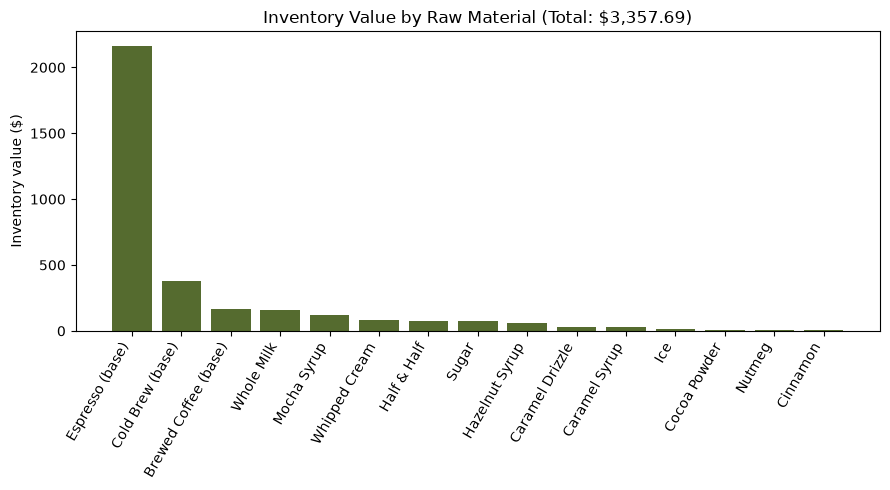

In [132]:
fig, ax = plt.subplots()
ax.bar(inv_value['item_name'], inv_value['inventory_value'], color='#556b2f')
ax.set_ylabel('Inventory value ($)')
ax.set_title(f"Inventory Value by Raw Material (Total: ${inv_value['inventory_value'].sum():,.2f})")
ax.tick_params(axis='x', rotation=60)
for label in ax.get_xticklabels():
    label.set_ha('right')
plt.tight_layout()
plt.show()

## 7. Fulfillment & Substitutions
What happened when a customer's first choice was out of stock: did they take a substitute, or leave without ordering?

In [133]:
fulfillment_summary = pd.read_sql_query('''
    SELECT
        CASE
            WHEN original_item_id IS NOT NULL THEN 'substituted'
            WHEN fulfilled = 1 THEN 'fulfilled_direct'
            ELSE 'stockout_no_sale'
        END AS outcome,
        COUNT(*) AS n
    FROM order_lines
    GROUP BY outcome
''', conn)
fulfillment_summary

,outcome,n
0,fulfilled_direct,8779
1,stockout_no_sale,1
2,substituted,3


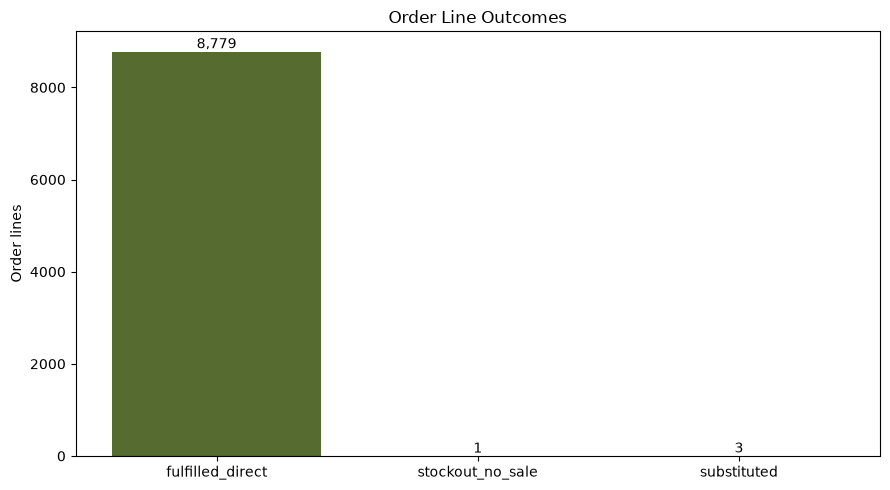

In [134]:
fig, ax = plt.subplots()
colors = {'fulfilled_direct': '#556b2f', 'substituted': '#c8a97e', 'stockout_no_sale': '#b22222'}
ax.bar(fulfillment_summary['outcome'], fulfillment_summary['n'],
       color=[colors[o] for o in fulfillment_summary['outcome']])
ax.set_ylabel('Order lines')
ax.set_title('Order Line Outcomes')
for i, n in enumerate(fulfillment_summary['n']):
    ax.text(i, n, f'{n:,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

### 7a. Substitution pairs
What customers originally wanted vs. what they actually walked away with.

In [135]:
substitutions = pd.read_sql_query('''
    SELECT orig.item_code AS wanted, new.item_code AS got, COUNT(*) AS n
    FROM order_lines ol
    JOIN items orig ON orig.item_id = ol.original_item_id
    JOIN items new ON new.item_id = ol.item_id
    WHERE ol.original_item_id IS NOT NULL
    GROUP BY wanted, got
    ORDER BY n DESC
''', conn)
substitutions

,wanted,got,n
0,FG-FRAPPE-CARAMEL,FG-AMERICANO,1
1,FG-FRAPPE-CARAMEL,FG-COLDBREW,1
2,FG-FRAPPE-CARAMEL,FG-FRAPPE-MOCHA,1


### 7b. Which items cause the most substitutions away from them?
A proxy for which items run out most relative to demand -- worth cross-referencing with the inventory reorder analysis in section 4.

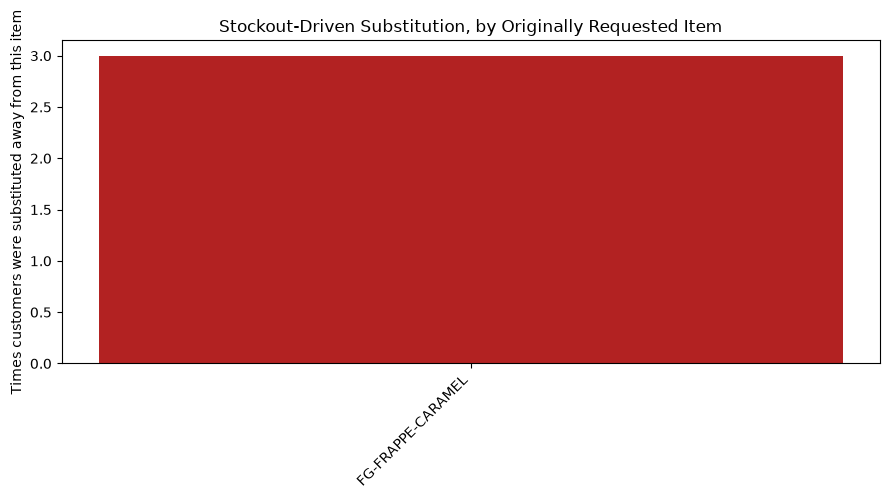

In [136]:
lost_demand_by_item = (substitutions.groupby('wanted')['n'].sum()
                                     .sort_values(ascending=False))

fig, ax = plt.subplots()
ax.bar(lost_demand_by_item.index, lost_demand_by_item.values, color='#b22222')
ax.set_ylabel('Times customers were substituted away from this item')
ax.set_title('Stockout-Driven Substitution, by Originally Requested Item')
ax.tick_params(axis='x', rotation=45)
for label in ax.get_xticklabels():
    label.set_ha('right')
plt.tight_layout()
plt.show()

### 7c. Fully lost sales (no substitute taken)

In [137]:
lost_sales = pd.read_sql_query('''
    SELECT it.item_code, o.order_date, ol.quantity, ol.unit_price
    FROM order_lines ol
    JOIN items it ON it.item_id = ol.item_id
    JOIN orders o ON o.order_id = ol.order_id
    WHERE ol.fulfilled = 0
    ORDER BY o.order_date
''', conn)
print(f"Total lost revenue: ${(lost_sales['quantity'] * lost_sales['unit_price']).sum():,.2f}")
lost_sales

Total lost revenue: $5.75


,item_code,order_date,quantity,unit_price
0,FG-FRAPPE-CARAMEL,2026-07-07 08:09:00,1.0,5.75


## 8. Orders overview
Now populated by simulate_orders.py + inventory_engine.py.


In [138]:
orders = pd.read_sql_query('SELECT * FROM orders', conn)
order_lines = pd.read_sql_query('SELECT * FROM order_lines', conn)
print(f'{len(orders)} orders, {len(order_lines)} order lines')
orders.head()

7472 orders, 8783 order lines


,order_id,customer_id,order_date,status
0,1,1,2026-06-04 07:38:00,completed
1,2,1,2026-06-04 14:47:00,completed
2,3,1,2026-06-04 08:41:00,completed
3,4,10,2026-06-04 15:38:00,completed
4,5,1,2026-06-04 13:43:00,completed


In [139]:
conn.close()